# Customer Churn Prediction Using Machine Learning

## Project Objective

To analyze historical customer data and build a machine learning model that predicts whether a customer is likely to churn.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
df[df["TotalCharges"].str.strip() == ""]["tenure"]

,tenure
488,0
753,0
936,0
1082,0
1340,0
3331,0
3826,0
4380,0
5218,0
6670,0


In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df = df.dropna(subset=["TotalCharges"])

In [ ]:
df.shape

(7032, 21)

In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


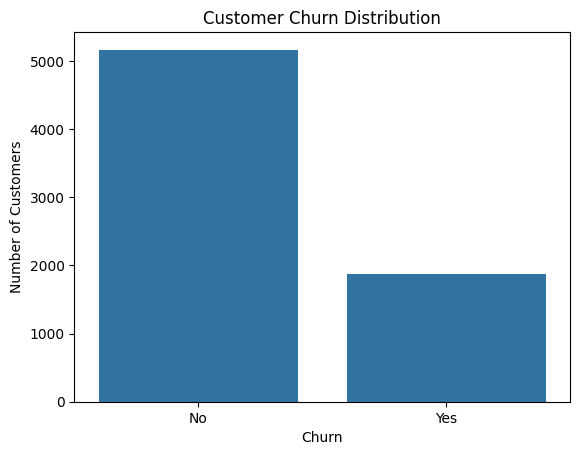

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


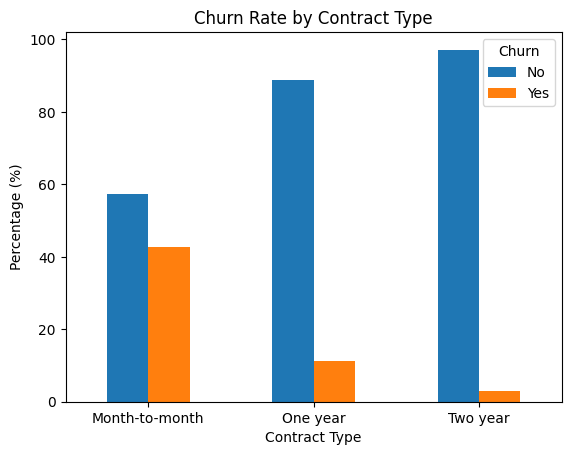

In [ ]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    stacked=False
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

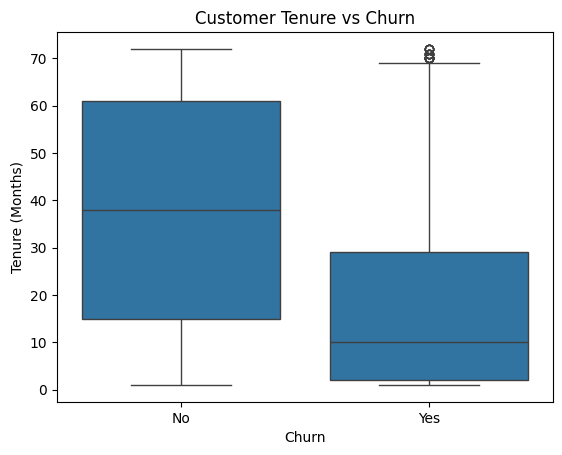

In [ ]:
sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

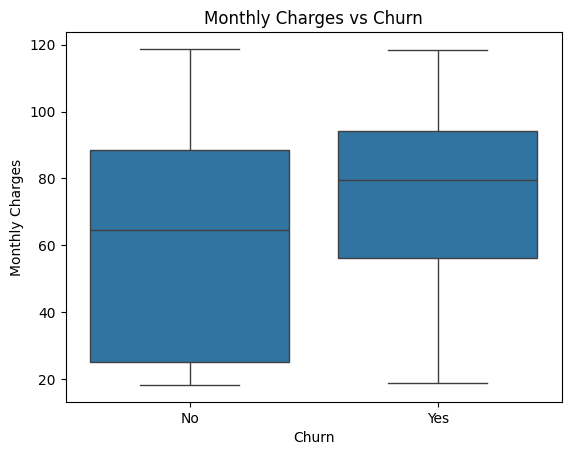

In [ ]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df = df.drop("customerID", axis=1)

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [ ]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
print("New features shape:", X.shape)

New features shape: (7032, 30)


In [ ]:
y = y.map({"No": 0, "Yes": 1})

In [ ]:
y.value_counts()

,count
Churn,
0,5163
1,1869


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (5625, 30)
Testing features: (1407, 30)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

[0 1 0 0 0 0 0 0 1 0]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8031272210376688
Accuracy (%): 80.31272210376687


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Remove missing TotalCharges rows
df = df.dropna(subset=["TotalCharges"])

# Remove customer ID
df = df.drop("customerID", axis=1)

# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Convert categorical columns into numbers
X = pd.get_dummies(X, drop_first=True)

# Convert target into 0 and 1
y = y.map({"No": 0, "Yes": 1})

print("X and y recreated successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

X and y recreated successfully!
X shape: (7032, 30)
y shape: (7032,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Train-test split completed!
Training data: (5625, 30)
Testing data: (1407, 30)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred[:10])

Predictions completed!
[0 1 0 0 0 0 0 0 1 0]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8031272210376688
Accuracy (%): 80.31272210376687

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



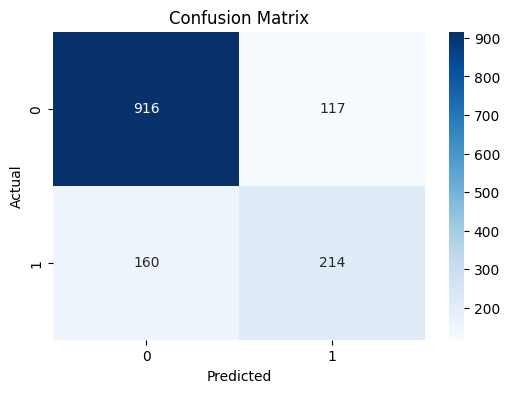

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

Decision Tree Accuracy: 77.82515991471215

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

forest_accuracy = accuracy_score(y_test, forest_pred)

print("Random Forest Accuracy:", forest_accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, forest_pred))

Random Forest Accuracy: 78.89125799573561

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy (%)": [
        accuracy * 100,
        tree_accuracy * 100,
        forest_accuracy * 100
    ]
})

comparison

,Model,Accuracy (%)
0,Logistic Regression,80.312722
1,Decision Tree,77.825160
2,Random Forest,78.891258


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                           Feature  Importance
1                           tenure    0.182865
3                     TotalCharges    0.160851
2                   MonthlyCharges    0.124068
10     InternetService_Fiber optic    0.064206
25               Contract_Two year    0.059125
28  PaymentMethod_Electronic check    0.057469
13              OnlineSecurity_Yes    0.037121
24               Contract_One year    0.033782
19                 TechSupport_Yes    0.027195
26            PaperlessBilling_Yes    0.021329


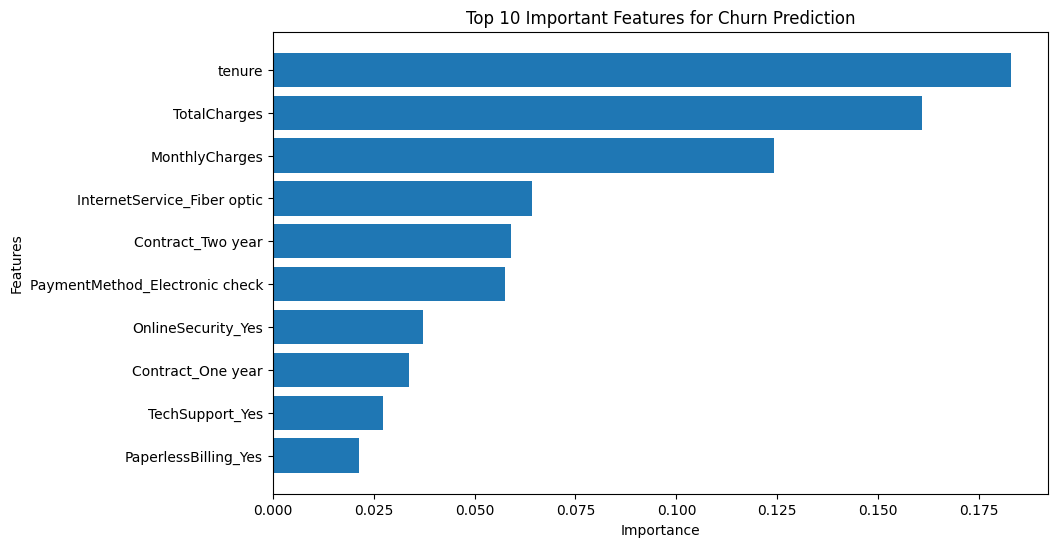

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features for Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy (%)": [
        accuracy_score(y_test, y_pred) * 100,
        accuracy_score(y_test, tree_pred) * 100,
        accuracy_score(y_test, forest_pred) * 100
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, forest_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, forest_pred)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, forest_pred)
    ]
})

results

,Model,Accuracy (%),Precision,Recall,F1-Score
0,Logistic Regression,80.312722,0.646526,0.572193,0.607092
1,Decision Tree,77.825160,0.580729,0.596257,0.588391
2,Random Forest,78.891258,0.628763,0.502674,0.558692


In [ ]:
from sklearn.metrics import roc_auc_score

logistic_prob = model.predict_proba(X_test)[:, 1]
tree_prob = tree_model.predict_proba(X_test)[:, 1]
forest_prob = forest_model.predict_proba(X_test)[:, 1]

print("Logistic Regression AUC:",
      roc_auc_score(y_test, logistic_prob))

print("Decision Tree AUC:",
      roc_auc_score(y_test, tree_prob))

print("Random Forest AUC:",
      roc_auc_score(y_test, forest_prob))

Logistic Regression AUC: 0.8363897790040947
Decision Tree AUC: 0.8195096572466881
Random Forest AUC: 0.8344614357227534


In [ ]:
results["ROC-AUC"] = [
    roc_auc_score(y_test, logistic_prob),
    roc_auc_score(y_test, tree_prob),
    roc_auc_score(y_test, forest_prob)
]

results

,Model,Accuracy (%),Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,80.312722,0.646526,0.572193,0.607092,0.836390
1,Decision Tree,77.825160,0.580729,0.596257,0.588391,0.819510
2,Random Forest,78.891258,0.628763,0.502674,0.558692,0.834461


In [ ]:
# Calculate churn rate by contract type

contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Churn Rate (%)")
)

contract_churn_rate

,Contract,Churn Rate (%)
0,Month-to-month,42.709677
1,One year,11.277174
2,Two year,2.848665


In [ ]:
# Create tenure groups

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ],
    include_lowest=True
)

# Calculate churn rate

tenure_churn_rate = (
    df.groupby("TenureGroup", observed=False)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Churn Rate (%)")
)

tenure_churn_rate

,TenureGroup,Churn Rate (%)
0,0-12 months,47.678161
1,13-24 months,28.710938
2,25-48 months,20.388959
3,49-72 months,9.513176


In [ ]:
internet_churn_rate = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Churn Rate (%)")
)

internet_churn_rate

,InternetService,Churn Rate (%)
0,DSL,18.998344
1,Fiber optic,41.892765
2,No,7.434211


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

  InternetService  Churn Rate (%)
0             DSL       18.998344
1     Fiber optic       41.892765
2              No        7.434211


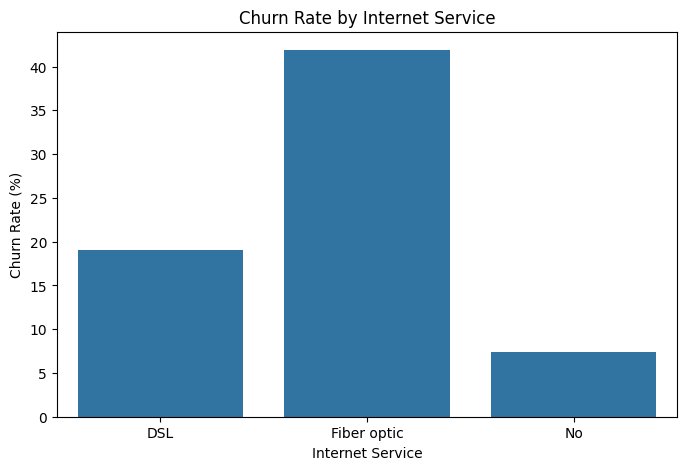

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Convert TotalCharges to numbers
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# 3. Remove missing TotalCharges rows
df = df.dropna(subset=["TotalCharges"])

# 4. Calculate churn rate by Internet Service
internet_churn_rate = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Churn Rate (%)")
)

# 5. Display the table
print(internet_churn_rate)

# 6. Create the graph
plt.figure(figsize=(8, 5))

sns.barplot(
    data=internet_churn_rate,
    x="InternetService",
    y="Churn Rate (%)"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

In [ ]:

# Import libraries
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# 1. Load dataset
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Clean data
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df = df.dropna(subset=["TotalCharges"])

# 3. Separate features and target
X = df.drop(["customerID", "Churn"], axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

# 4. Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Create models
model = LogisticRegression(max_iter=1000)

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

# 7. Train models
model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

# 8. Generate predictions
y_pred = model.predict(X_test)
tree_pred = tree_model.predict(X_test)
forest_pred = forest_model.predict(X_test)

# 9. Generate probabilities
logistic_prob = model.predict_proba(X_test)[:, 1]
tree_prob = tree_model.predict_proba(X_test)[:, 1]
forest_prob = forest_model.predict_proba(X_test)[:, 1]

print("All three models trained successfully!")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


All three models trained successfully!


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy (%)": [
        accuracy_score(y_test, y_pred) * 100,
        accuracy_score(y_test, tree_pred) * 100,
        accuracy_score(y_test, forest_pred) * 100
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, forest_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, forest_pred)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, forest_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, tree_prob),
        roc_auc_score(y_test, forest_prob)
    ]
})

results.round(4)

,Model,Accuracy (%),Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,80.3127,0.6465,0.5722,0.6071,0.8364
1,Decision Tree,77.8252,0.5807,0.5963,0.5884,0.8195
2,Random Forest,78.8913,0.6288,0.5027,0.5587,0.8345


In [ ]:
results.round(4).to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [ ]:
import joblib

# Save the Logistic Regression model
joblib.dump(model, "churn_model.pkl")

# Save the feature columns used during training
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Model saved successfully!")
print("Feature columns saved successfully!")

Model saved successfully!
Feature columns saved successfully!


In [ ]:
!pip install gradio

In [ ]:
import pandas as pd
import numpy as np
import joblib

# Load the saved model and feature columns
model = joblib.load("churn_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")

# Create default customer details
default_row = df.drop(
    columns=["Churn"],
    errors="ignore"
).mode().iloc[0].to_dict()


def predict_churn(
    contract,
    tenure,
    monthly_charges,
    total_charges,
    internet_service
):
    # Copy default customer details
    customer = default_row.copy()

    # Update the details entered by the user
    customer["Contract"] = contract
    customer["tenure"] = tenure
    customer["MonthlyCharges"] = monthly_charges
    customer["TotalCharges"] = total_charges
    customer["InternetService"] = internet_service

    # Convert into a DataFrame
    input_df = pd.DataFrame([customer])

    # Convert categorical values into numerical columns
    input_df = pd.get_dummies(input_df, drop_first=True)

    # Match the training columns
    input_df = input_df.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # Make prediction
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    # Display result
    if prediction == 1:
        result = "Customer is likely to churn"
    else:
        result = "Customer is likely to stay"

    return result, f"Churn Probability: {probability:.2%}"


print("Prediction function created successfully!")

Prediction function created successfully!


In [ ]:
import gradio as gr

app = gr.Interface(
    fn=predict_churn,
    inputs=[
        gr.Dropdown(
            choices=[
                "Month-to-month",
                "One year",
                "Two year"
            ],
            label="Contract Type",
            value="Month-to-month"
        ),

        gr.Number(
            label="Tenure (Months)",
            value=5
        ),

        gr.Number(
            label="Monthly Charges",
            value=70
        ),

        gr.Number(
            label="Total Charges",
            value=350
        ),

        gr.Dropdown(
            choices=[
                "DSL",
                "Fiber optic",
                "No"
            ],
            label="Internet Service",
            value="DSL"
        )
    ],

    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Probability")
    ],
        flagging_mode="never",

    title="Customer Churn Prediction System",

    description=(
        "Enter customer details to predict "
        "whether the customer is likely to churn."
    )
)

print("Application created successfully!")

Application created successfully!


In [ ]:
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f8916a378d7d6ba490.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:

# ==========================================
# CUSTOMER CHURN PREDICTION
# COMPLETE RECOVERY CODE
# ==========================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ==========================================
# 2. UPLOAD DATASET
# ==========================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Original shape:", df.shape)

# ==========================================
# 3. DATA CLEANING
# ==========================================

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Remove missing values
df = df.dropna(subset=["TotalCharges"])

# Remove duplicate records
df = df.drop_duplicates()

print("Data cleaning completed!")
print("Final shape:", df.shape)

# ==========================================
# 4. PREPROCESSING
# ==========================================

# Remove customer ID
df = df.drop("customerID", axis=1)

# Separate input and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

# Convert target values
y = y.map({
    "No": 0,
    "Yes": 1
})

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Preprocessing completed!")
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# ==========================================
# 5. TRAIN MACHINE LEARNING MODELS
# ==========================================

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Decision Tree
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)
tree_model.fit(X_train, y_train)

# Random Forest
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)
forest_model.fit(X_train, y_train)

print("All models trained successfully!")

# ==========================================
# 6. MAKE PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)
tree_pred = tree_model.predict(X_test)
forest_pred = forest_model.predict(X_test)

logistic_prob = model.predict_proba(X_test)[:, 1]
tree_prob = tree_model.predict_proba(X_test)[:, 1]
forest_prob = forest_model.predict_proba(X_test)[:, 1]

# ==========================================
# 7. EVALUATE MODELS
# ==========================================

def evaluate_model(name, predictions, probabilities):

    return {
        "Model": name,
        "Accuracy (%)": accuracy_score(
            y_test, predictions
        ) * 100,

        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),

        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),

        "F1-Score": f1_score(
            y_test, predictions, zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test, probabilities
        )
    }


results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_pred,
        logistic_prob
    ),

    evaluate_model(
        "Decision Tree",
        tree_pred,
        tree_prob
    ),

    evaluate_model(
        "Random Forest",
        forest_pred,
        forest_prob
    )
])

print("MODEL EVALUATION RESULTS")
display(results.round(4))

# ==========================================
# 8. SAVE MODEL AND FEATURE COLUMNS
# ==========================================

joblib.dump(model, "churn_model.pkl")

joblib.dump(
    X.columns.tolist(),
    "feature_columns.pkl"
)

print("Model saved successfully!")
print("Feature columns saved successfully!")

# ==========================================
# 9. CREATE PREDICTION FUNCTION
# ==========================================

feature_columns = joblib.load(
    "feature_columns.pkl"
)

# Use the most common value for each feature
default_row = df.drop(
    columns=["Churn"],
    errors="ignore"
).mode().iloc[0].to_dict()


def predict_churn(
    contract,
    tenure,
    monthly_charges,
    total_charges,
    internet_service
):

    customer = default_row.copy()

    customer["Contract"] = contract
    customer["tenure"] = tenure
    customer["MonthlyCharges"] = monthly_charges
    customer["TotalCharges"] = total_charges
    customer["InternetService"] = internet_service

    input_df = pd.DataFrame([customer])

    input_df = pd.get_dummies(
        input_df,
        drop_first=True
    )

    input_df = input_df.reindex(
        columns=feature_columns,
        fill_value=0
    )

    prediction = model.predict(input_df)[0]

    probability = model.predict_proba(
        input_df
    )[0][1]

    if prediction == 1:
        result = "Customer is likely to churn"
    else:
        result = "Customer is likely to stay"

    return (
        result,
        f"Churn Probability: {probability:.2%}"
    )


print("Prediction function created successfully!")

# ==========================================
# 10. CREATE GRADIO APPLICATION
# ==========================================

import gradio as gr

app = gr.Interface(
    fn=predict_churn,

    inputs=[
        gr.Dropdown(
            choices=[
                "Month-to-month",
                "One year",
                "Two year"
            ],
            label="Contract Type",
            value="Month-to-month"
        ),

        gr.Number(
            label="Tenure (Months)",
            value=5
        ),

        gr.Number(
            label="Monthly Charges",
            value=70
        ),

        gr.Number(
            label="Total Charges",
            value=350
        ),

        gr.Dropdown(
            choices=[
                "DSL",
                "Fiber optic",
                "No"
            ],
            label="Internet Service",
            value="DSL"
        )
    ],

    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Probability")
    ],

    title="Customer Churn Prediction System",

    description=(
        "Enter customer details to predict "
        "whether the customer is likely to churn."
    ),

    flagging_mode="never"
)

print("Application created successfully!")

# ==========================================
# 11. LAUNCH APPLICATION
# ==========================================

app.launch(share=True)

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Dataset loaded successfully!
Original shape: (7043, 21)
Data cleaning completed!
Final shape: (7032, 21)
Preprocessing completed!
Training shape: (5625, 30)
Testing shape: (1407, 30)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


All models trained successfully!
MODEL EVALUATION RESULTS


,Model,Accuracy (%),Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,80.3127,0.6465,0.5722,0.6071,0.8364
1,Decision Tree,77.8252,0.5807,0.5963,0.5884,0.8195
2,Random Forest,78.8913,0.6288,0.5027,0.5587,0.8345


Model saved successfully!
Feature columns saved successfully!
Prediction function created successfully!
Application created successfully!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://593c573df0b3b722af.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
